# Notebook 2: Exploratory Data Analysis

## Overview

This notebook conducts exploratory data analysis on the MENA panel dataset to:
1. Assess data quality and completeness
2. Generate descriptive statistics  
3. Visualize temporal trends and cross-country patterns
4. Examine correlations between key variables
5. Identify potential confounding factors

Thorough EDA is essential before causal analysis to understand data characteristics, detect anomalies, and verify sufficient variation for estimation.

---


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from data_processing import load_panel_data, handle_missing_data, calculate_summary_stats
from visualization import plot_trends, plot_correlation_matrix, plot_scatter_with_regression

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
print("✓ Libraries loaded successfully!")


✓ Libraries loaded successfully!


## Load Data

Raw data from Notebook 1 is loaded and passed through the initial cleaning pipeline before analysis.


In [2]:
# Load raw data
df = load_panel_data('../data/raw/mena_panel_raw.csv')

print(f"\nDataset Overview:")
print(f"  Time period: {df['year'].min()} - {df['year'].max()}")
print(f"  Number of countries: {df['country_code'].nunique()}")
print(f"  Total observations: {len(df)}")
print(f"  Variables: {df.shape[1]}")

# Display first few rows
print("\nFirst 5 rows:")
display(df.head())


✓ Data loaded: 646 rows × 11 columns

Dataset Overview:
  Time period: 1990 - 2023
  Number of countries: 19
  Total observations: 646
  Variables: 11

First 5 rows:


,country_code,country,year,tertiary_enrollment,youth_unemployment,gdp_per_capita,population_growth,education_spending,urban_population,working_age_pop,labor_force_participation
0,ARE,United Arab Emirates,1990,NaN,NaN,66979.155915,5.878423,NaN,79.051,69.391851,74.385
1,ARE,United Arab Emirates,1991,NaN,3.912,63905.626470,5.553810,NaN,78.906,70.143956,74.654
2,ARE,United Arab Emirates,1992,NaN,4.048,62667.135448,5.247244,NaN,78.760,70.888530,74.952
3,ARE,United Arab Emirates,1993,NaN,4.283,60391.465584,4.952240,NaN,78.614,71.608958,75.464
4,ARE,United Arab Emirates,1994,NaN,4.298,61614.341591,4.664074,NaN,78.467,72.321136,75.812


## Descriptive Statistics

Summary statistics for all panel variables. Variability across countries and years is a prerequisite for identification.


In [3]:
# Summary statistics for key variables
key_vars = ['tertiary_enrollment', 'youth_unemployment', 'gdp_per_capita', 
            'population_growth', 'education_spending']

summary = df[key_vars].describe().T
summary['missing_pct'] = (df[key_vars].isnull().sum() / len(df) * 100).values

print("Summary Statistics:\n")
display(summary.round(2))


Summary Statistics:



,count,mean,std,min,25%,50%,75%,max,missing_pct
tertiary_enrollment,411.0,29.39,16.68,0.00,15.89,28.32,42.74,77.97,36.38
youth_unemployment,626.0,24.63,16.27,0.30,14.60,22.17,32.56,82.41,3.10
gdp_per_capita,614.0,14064.23,17243.40,669.90,2952.60,4543.85,22241.91,81608.57,4.95
population_growth,645.0,2.66,2.98,-27.47,1.49,2.23,3.53,21.70,0.15
education_spending,276.0,4.64,1.84,1.33,3.24,4.43,5.95,14.20,57.28


## Temporal Trends

Time-series plots of tertiary enrollment (treatment) and youth unemployment (outcome) averaged across the MENA panel.


✓ Figure saved: ../results/figures/02_main_trends.png


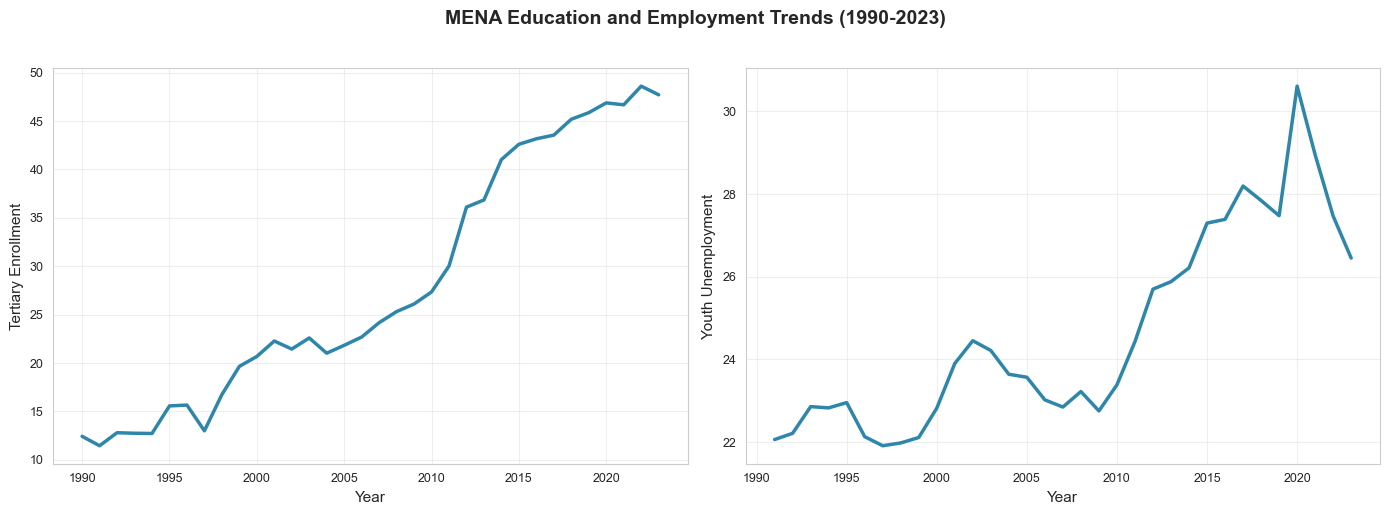

In [4]:
# Plot trends over time
plot_trends(df, 
           time_col='year',
           variables=['tertiary_enrollment', 'youth_unemployment'],
           title='MENA Education and Employment Trends (1990-2023)',
           figsize=(14, 5),
           save_path='../results/figures/02_main_trends.png')


### Interpretation

Tertiary enrollment has risen steadily across the panel period while youth unemployment has remained persistently high (~25–30%). This divergence motivates the causal question: does enrollment expansion reduce unemployment, or does the relationship reflect structural factors unrelated to education policy?


## Correlation Analysis

Pairwise correlations identify potential multicollinearity among controls and flag variables likely to confound the enrollment–unemployment relationship.


✓ Figure saved: ../results/figures/02_correlation_matrix.png


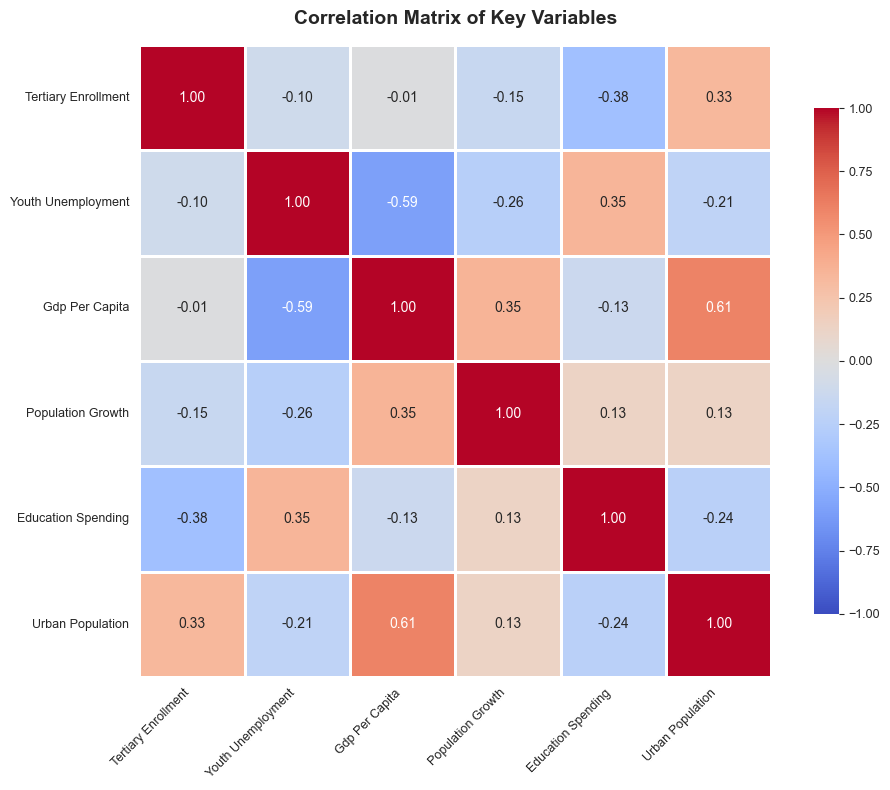

In [5]:
# Correlation matrix for key variables
corr_vars = ['tertiary_enrollment', 'youth_unemployment', 'gdp_per_capita',
             'population_growth', 'education_spending', 'urban_population']

plot_correlation_matrix(df, 
                       variables=corr_vars,
                       title='Correlation Matrix of Key Variables',
                       figsize=(10, 8),
                       save_path='../results/figures/02_correlation_matrix.png')


## Country-Level Variation

Cross-country dispersion in enrollment and unemployment rates informs treatment/control group construction in Notebook 3.


Country Averages (2010-2023):



,tertiary_enrollment,youth_unemployment
country,,
Saudi Arabia,58.40,24.93
"Iran, Islamic Rep.",58.31,25.76
United Arab Emirates,56.71,7.45
Kuwait,54.64,14.64
Bahrain,48.96,5.55
Lebanon,47.73,21.40
West Bank and Gaza,45.62,38.10
Algeria,44.48,28.89
Oman,41.24,13.17


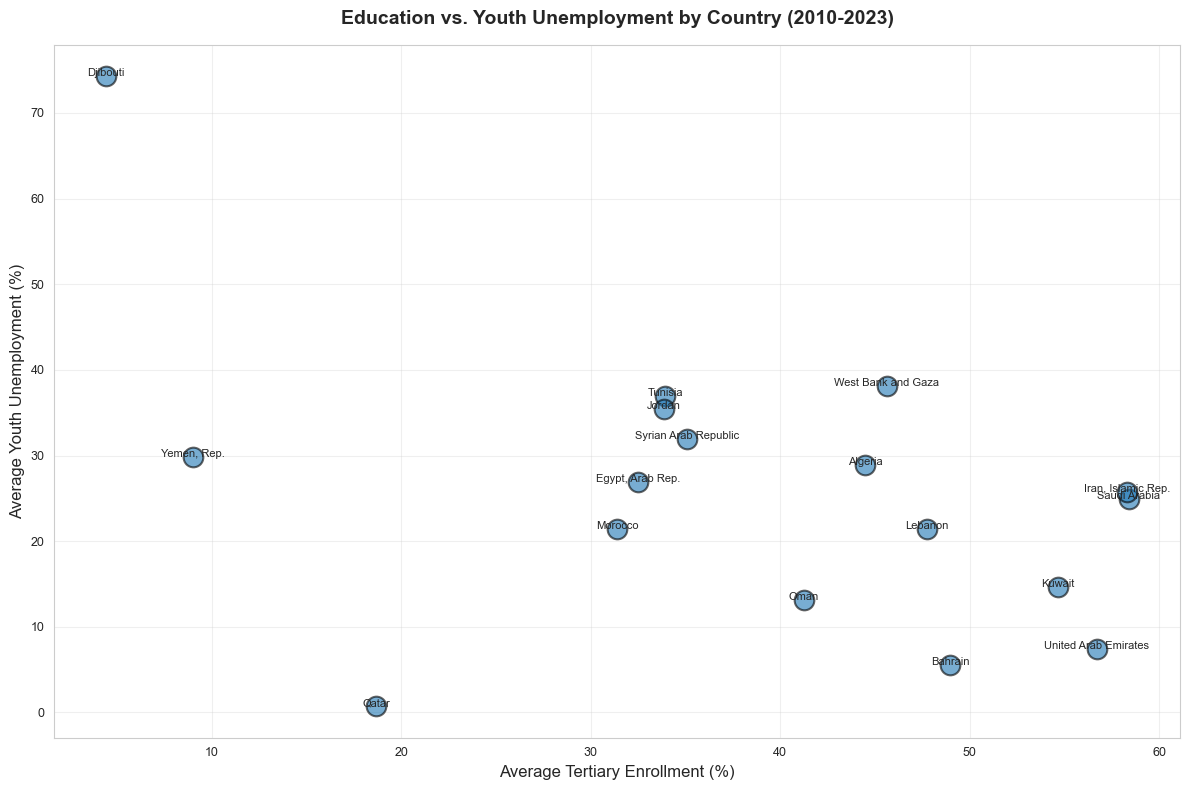

In [6]:
# Calculate country averages (2010-2023 period)
recent_df = df[df['year'] >= 2010].copy()
country_avg = recent_df.groupby('country')[['tertiary_enrollment', 'youth_unemployment']].mean().round(2)
country_avg = country_avg.sort_values('tertiary_enrollment', ascending=False)

print("Country Averages (2010-2023):\n")
display(country_avg)

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(country_avg['tertiary_enrollment'], 
                    country_avg['youth_unemployment'],
                    s=200, alpha=0.6, edgecolors='black', linewidth=1.5)

for idx, country in enumerate(country_avg.index):
    ax.annotate(country, 
               (country_avg.iloc[idx, 0], country_avg.iloc[idx, 1]),
               fontsize=8, ha='center')

ax.set_xlabel('Average Tertiary Enrollment (%)', fontsize=12)
ax.set_ylabel('Average Youth Unemployment (%)', fontsize=12)
ax.set_title('Education vs. Youth Unemployment by Country (2010-2023)', 
            fontsize=14, fontweight='bold', pad=15)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/02_country_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


## Save Cleaned Data

Cleaned panel data is saved for use in subsequent estimation notebooks.


In [7]:
# Handle missing data using forward fill within countries
df_clean = handle_missing_data(df, strategy='forward_fill', threshold=0.7)

# Drop rows with remaining missing values in key variables
key_vars = ['tertiary_enrollment', 'youth_unemployment', 'gdp_per_capita']
df_clean = df_clean.dropna(subset=key_vars)

print(f"\nCleaned dataset:")
print(f"  Observations: {len(df_clean)} (from {len(df)})")
print(f"  Remaining missing data: {df_clean.isnull().sum().sum()} cells")

# Save cleaned data
df_clean.to_csv('../data/processed/mena_panel_clean.csv', index=False)
print("\n✓ Cleaned data saved to: ../data/processed/mena_panel_clean.csv")


Dropped 0 variables with >70.0% missing data

Cleaned dataset:
  Observations: 526 (from 646)
  Remaining missing data: 96 cells

✓ Cleaned data saved to: ../data/processed/mena_panel_clean.csv


## Summary

The MENA panel exhibits substantial cross-country and temporal variation in both the treatment and outcome variables. GDP per capita, urbanization, and education spending are meaningfully correlated with both, confirming their role as confounders. Data completeness is adequate for panel estimation after imputation.

Notebook 3 defines the treatment indicator and verifies covariate balance between groups.
